# Lab 1 - Binary classification

Linear regression is the fitting of a linear model to a set of input/output points. This model relies on the assumption that the ouputs are **quantitative** values. When this assumption does not hold, which is typically the case for **qualitative** output values, linear regression performs rather poorly. This naturally leads to the exploration of fitting a nonlinear function to data, referred to in general as nonlinear regression.

In this notebook, we will introduce the simplest form of **qualitative** prediction, which is **binary classification**. The main difference with respect to linear regression lies in the data itself, and more particularly in its outputs, which can take on only one of two values. This subtle difference is important, and spurs the development of new cost functions that are better-suited to deal with such data. Moreover, these new cost functions are formulated based on a wide array of motivating perspectives, each leading to a different model, such as logistic regression, support vector machines, or neural networks.

# Part 1. Support vector machine

Support vector machines (SVMs) are a set of supervised learning methods used for classification, regression and outliers detection. They are memory efficient, effective in high dimensional spaces, and different Kernel functions can be specified for the decision function. However, SVMs do not directly provide probability estimates, as opposed to logistic regression. In this part of the notebook, you will gain an intuition of 
- how SVMs work
- how to use a Gaussian kernel
- how to set the associated hyperparameters.

## Required packages

For this part of the notebook, you need to import the following packages.
- [**Numpy**](www.numpy.org) - Library for scientific computing.
- [**Matplotlib**](http://matplotlib.org) - Library for plotting graphs.
- [**Scikit Learn**](https://scikit-learn.org/stable/index.html) - Library for machine learning.
- [**NLTK**](https://www.nltk.org) - Library for natural language processing.

*Run the following cells.*

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [68]:
def show_svm(model, x, y, figsize=(7,6)):    
    grid = (np.linspace(x[:,i].min()-0.1, x[:,i].max()+0.1) for i in range(x.shape[1]))
    x0, x1 = np.meshgrid(*grid)
    xx = np.c_[x0.ravel(), x1.ravel()]
    yy = model.decision_function(xx)
    yy = yy.reshape(x0.shape)
    
    scores = model.decision_function(x)
    ridx = np.where(np.abs(scores) <= 1 + 1e-15)
    support = x[ridx]
    
    plt.figure(figsize=figsize)
    plt.scatter(x[:,0], x[:,1], c=y, cmap='coolwarm', alpha=0.6)
    plt.contour(x0, x1, yy, colors='k', levels=[0], alpha=0.8)
    plt.scatter(support[:, 0], support[:, 1], s=150, facecolors='none', edgecolors='k', alpha=0.6, label='Support vectors')
    plt.plot([], 'k', label='Classifier')
    plt.legend(fontsize=14)

## Linear SVM

Let us begin with a 2D dataset that can be separated by a linear split. You can visualize the data as points in a two-dimensional space, using a different color according to which class they belong to. The position of the samples in the scatter plot suggests a natural separation. However, there is an outlier on the far left: as part of this first exercise, you will also see how this outlier affects the SVM.

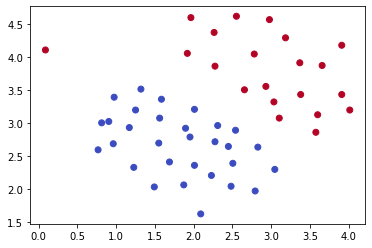

In [69]:
data = loadmat('lab01_data/data1.mat')

x = data['X']
y = data['y'].ravel()

plt.scatter(x[:,0], x[:,1], c=y, cmap='coolwarm');

For this dataset, you will use the model `LinearSVC` provided the scikit-learn library, which is a *linear SVM* classifier. The cell below shows how to train and test this model.

In [70]:
model = LinearSVC()        # Definition of the model - Here you may set the hyperparameters

model.fit(x, y)            # Training - Here you train the model on the data (x: feature matrix | y: label vector)

y_pred = model.predict(x)  # Prediction - Here you make predictions on (possibly new) data

print('Train accuracy:', 100 * np.sum(y==y_pred) / y.size)

Train accuracy: 98.03921568627452


To gain a better insight into the classification, you can visualize how the trained SVM splits the data. 

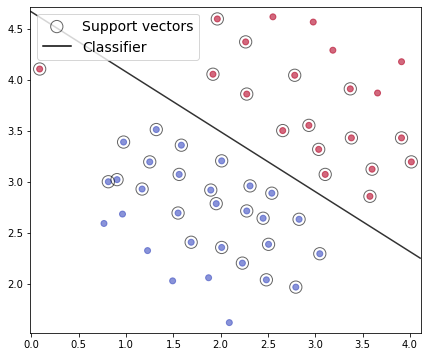

In [71]:
show_svm(model, x, y)

Linear SVM has an hyperparameter, usually named **C**, that controls the penalty for misclassified training samples (i.e., larger values force SVM to classify all the examples correctly). This hyperparameter can be set as an argument of the function `LinearSVC()`. Read the [**DOC**](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC) for more information.

*Warning:* When you set **C** to a large value, you will probably also need to set **max_iter** to a large number (e.g., `max_iter=1e6`).


### Quiz 1

> Go back to the previous cell of code, and train the SVM classifier with different values of **C**. 
> - Can you set **C** such that all samples are correctly classified? 
> - How does the margin change by increasing/reducing **C**? 
> - In your opinion, should the value of **C** be small or large in order to have a classifier that performs well on new data?

Quiz 1:
1. C is Regularization parameter (https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

C is 1 by default. When Regularization parameter (C) is increased, the classifier tries to optimise itself. But the max_iter needs to be set as high for a higher value of C as it needs more iterations to accomodate for a higher value of C.

2. Margin is the wide gap around the classifier from blue circled dots to red circled dots. As the value of C increases, the margin decreases (the dots are classified well, so the margin decreases).

3. For a large value of C along with a correspondingly large value of max_iter, the classification works well.

Note: 100% accuracy in training data leads to over fitting. Avoid over fitting for model to adapt well to new data set.


    

Train accuracy: 100.0


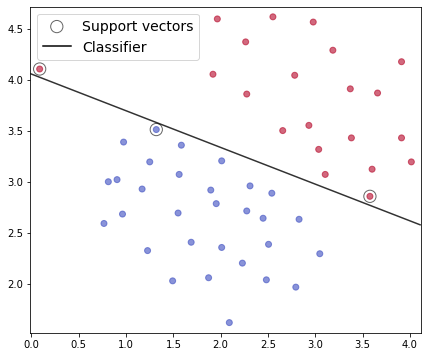

In [96]:
model2 = LinearSVC(C=2000,max_iter=1e9)        # Definition of the model - Here you may set the hyperparameters

model2.fit(x, y)            # Training - Here you train the model on the data (x: feature matrix | y: label vector)

y_pred1 = model2.predict(x)  # Prediction - Here you make predictions on (possibly new) data

print('Train accuracy:', 100 * np.sum(y==y_pred1) / y.size)

show_svm(model2, x, y)

In [97]:
# EXECUTE THIS CELL **ONLY AFTER** YOU ANSWERED THE QUIZ

del data, x, y, model, y_pred

## Nonlinear SVM

Let us move on to a different dataset. From the figure, you can observe that there is no linear split that separates the samples. However, by using the kernel trick, you will be able to learn a nonlinear SVM that can perform reasonably well for the dataset. 

Be aware that SVM classifiers are are not scale invariant, so it is **highly recommended to scale your data** when using a nonlinear kernel. For example, scale each attribute on the input vector to [0,1] or [-1,+1], or standardize it to have mean 0 and variance 1. Note that the same scaling must be applied to the test vector to obtain meaningful results. 

The simplest solution is to normalize the data manually, as shown below. But you could also use a pipeline in Scikit-Learn to automatize this process.

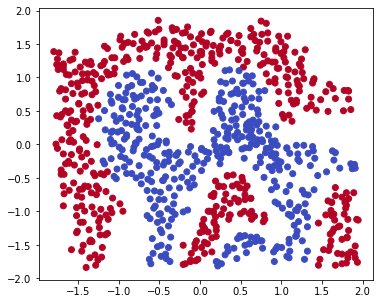

In [100]:
data = loadmat('lab01_data/data2.mat')

x = data['X']
y = data['y'].ravel()

#
# Normalization
#
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

plt.figure(figsize=(6,5))
plt.scatter(x[:,0], x[:,1], c=y, cmap='coolwarm');

For this dataset, you will use the model `SVC` provided the scikit-learn library , which is a *nonlinear SVM* classifier that uses the RBF kernel by default. The cell below shows how to train and test this model.

> **Remark:** If you did not normalize the data, you could use a pipeline as shown here.
>
> ```
model2 = make_pipeline(StandardScaler(), SVC())
```

Train accuracy: 98.84125144843568


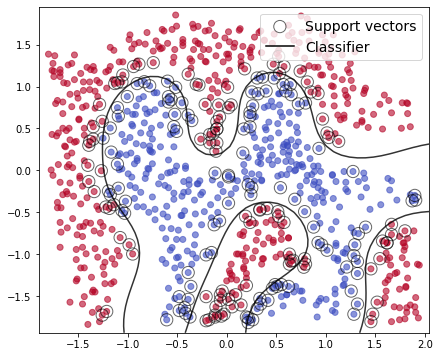

In [118]:
model = SVC(gamma=2)              # Definition of the model - Here you may set the hyperparameters

model.fit(x, y)            # Training - Here you train the model on the data (x: feature matrix | y: label vector)

y_pred = model.predict(x)  # Prediction - Here you make predictions on (possibly new) data

print('Train accuracy:', 100 * np.sum(y==y_pred) / y.size)

show_svm(model, x, y)

To gain a better insight into the classification, you can visualize how the trained SVM splits the data. 

Nonlinear SVM has several hyperparameters:
 - **C** - It controls the penalty for misclassified training samples (i.e., larger values force SVM to classify all the examples correctly).
 - **kernel** - It specifies the type of nonlinearity. The default is `'rbf'`.
 - **gamma** - Kernel coefficient with `'rbf'`. A large value tells the SVM to closely follow the samples.
 
These hyperparameters can be set as arguments of the function `SVC()`. Read the [**DOC**](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) for more information.


### Quiz 2

>Go back to the previous cell of code, and train the Nonlinear SVM classifier with different values of **gamma**. 
> - Can you set **gamma** such that all samples are correctly classified? 
> - In terms of fitting, what does it happen when **gamma** is too small or too big? 
> - In your opinion, should the value of **gamma** be small or large in order to have a classifier that performs well on new data?

Quiz 2:

1. gamma =2, classifies all the data points correctly. 98%
2. When gamma is too small, the data points are vaguely classified (less accuracy). When gamma is big, it over fits (100% (bad))

3. Not too large, not too small. Depends on test set. If works well in training and in test set, then model is good.

In [52]:
# EXECUTE THIS CELL **ONLY AFTER** YOU ANSWERED THE QUIZ

del data, x, y, scaler, model, y_pred

## Cross-validation

In this last exercise, you will gain more practical skills on how to use a SVM with the Gaussian kernel. The following cell loads another "non-separable" dataset, and properly normalize the data.

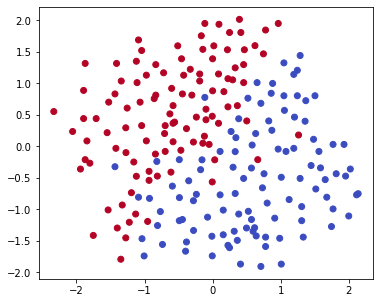

In [127]:
data = loadmat('lab01_data/data3.mat')

x_train = data['X']
y_train = data['y'].ravel()

x_val = data['Xval']
y_val = data['yval'].ravel()

#
# Normalization
#
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)

plt.figure(figsize=(6,5))
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='coolwarm');

There are actually two datasets: one for training, and the other for validation. Remember that the validation set is not used for training the SVM, but only for evaluating the classification error.

Accuracy (val.): 95.0


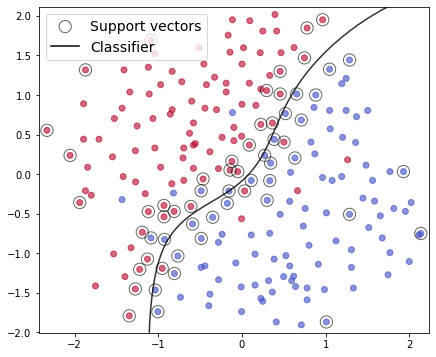

In [128]:
# hyperparameters
C = 1
gamma = 1

# training
model = SVC(C=C, gamma=gamma)
model.fit(x_train, y_train)

# prediction
y_pred = model.predict(x_val)

print('Accuracy (val.):', 100 * np.sum(y_val==y_pred) / y_val.size)

show_svm(model, x_train, y_train)

### Quiz 3
    
> Find the values of **C** and **gamma** such that the trained SVM obtains the best accuracy on the validation set. For both parameters, we suggest trying values in multiplicative steps: $0.01, 0.03, 0.1, 0.3, 1, 3, 10$. Note that you should try all possible pairs of values, so you will end up training a total of $7^2 = 49$ different SVMs. What are the best values of these hyperparameters?
        
*Hints:* 
 - To automatize the process, you can use two nested loops (see below for an example).
 - Scikit-Learn provides the function [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) that performs exactly the same process.

In [ ]:
C = 1,1, 9
gamma = 3,9,3
Accuracy (val.): 96.0
Accuracy (val.): 96.0

In [131]:
steps = [0.01, 0.03, 0.1, 0.3, 1, 3, 9]

for C in steps:
    for gamma in steps:
        model = SVC(C=C, gamma=gamma)
        model.fit(x_train, y_train)

        # prediction
        y_pred = model.predict(x_val)

        print(str(C)+" "+str(gamma)+'Accuracy (val.):', 100 * np.sum(y_val==y_pred) / y_val.size)
        
        pass # YOUR CODE HERE
    
    
    

0.01 0.01Accuracy (val.): 43.5
0.01 0.03Accuracy (val.): 43.5
0.01 0.1Accuracy (val.): 43.5
0.01 0.3Accuracy (val.): 43.5
0.01 1Accuracy (val.): 43.5
0.01 3Accuracy (val.): 43.5
0.01 9Accuracy (val.): 43.5
0.03 0.01Accuracy (val.): 43.5
0.03 0.03Accuracy (val.): 55.0
0.03 0.1Accuracy (val.): 92.5
0.03 0.3Accuracy (val.): 93.0
0.03 1Accuracy (val.): 93.0
0.03 3Accuracy (val.): 45.5
0.03 9Accuracy (val.): 43.5
0.1 0.01Accuracy (val.): 71.0
0.1 0.03Accuracy (val.): 91.5
0.1 0.1Accuracy (val.): 92.0
0.1 0.3Accuracy (val.): 94.0
0.1 1Accuracy (val.): 95.5
0.1 3Accuracy (val.): 95.0
0.1 9Accuracy (val.): 70.0
0.3 0.01Accuracy (val.): 91.0
0.3 0.03Accuracy (val.): 92.0
0.3 0.1Accuracy (val.): 93.0
0.3 0.3Accuracy (val.): 94.0
0.3 1Accuracy (val.): 95.0
0.3 3Accuracy (val.): 95.5
0.3 9Accuracy (val.): 96.0
1 0.01Accuracy (val.): 92.5
1 0.03Accuracy (val.): 92.5
1 0.1Accuracy (val.): 93.0
1 0.3Accuracy (val.): 95.0
1 1Accuracy (val.): 95.0
1 3Accuracy (val.): 96.0
1 9Accuracy (val.): 96.0
3 0.0

In [125]:
# EXECUTE THIS CELL **ONLY AFTER** YOU ANSWERED THE QUIZ

del data, x_train, y_train, x_val, y_val, scaler, model, y_pred, steps, C, gamma

---

# Part 2. Spam Classification

Many email services today provide spam filters that are able to classify emails with high accuracy. In this part of the notebook, you will learn how to classify if a given email is spam or non-spam using a linear SVM. 

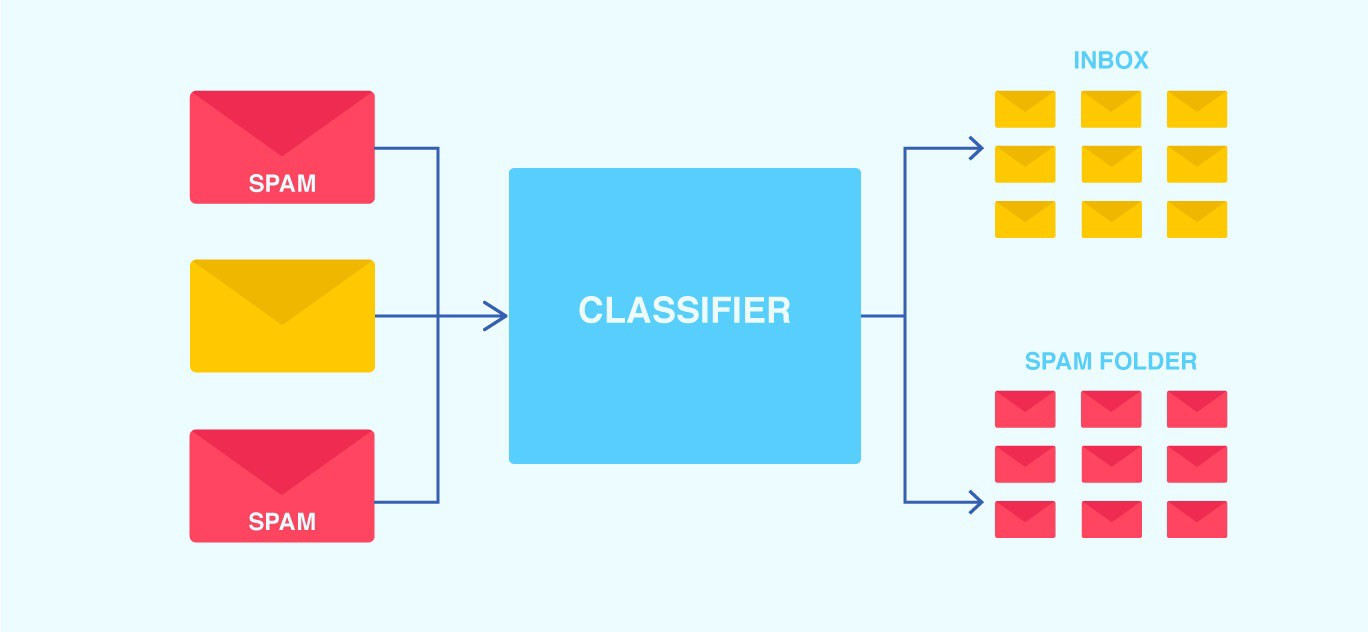

## Required packages

For this part of the notebook, you need to import the following packages.
- [**Numpy**](www.numpy.org) - Library for scientific computing.
- [**Matplotlib**](http://matplotlib.org) - Library for plotting graphs.
- [**Scikit Learn**](https://scikit-learn.org/stable/index.html) - Library for machine learning.
- [**NLTK**](https://www.nltk.org) - Library for natural language processing.
- [**WordCloud**](http://amueller.github.io/word_cloud/) - Library for isual representation of text.

*Run the following cell.*

---

**Installation:** WordCloud is not included in the standard Python installation. Open the terminal (Anaconda prompt on Windows) and execute the command:

```
pip install wordcloud
```

If you are not the admin, add the flag `--user` for a local installation, and **restart the notebook**.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem.snowball import EnglishStemmer
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from wordcloud import WordCloud

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SHAKTHI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHAKTHI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SHAKTHI\AppData\Roaming\nltk_data...


## Dataset

The dataset is based on a subset of the [SpamAssassin Public Corpus](http://spamassassin.apache.org/publiccorpus). Before starting on a machine learning task, it is usually insightful to take a look at examples from the dataset. Hereafter, you can see a sample email that contains some text, a URL, an email address, numbers, and dollar amounts.

In [141]:
with open('lab01_data/emailSample1.txt', 'r') as file:
    email = file.read()
    print(email)

> Anyone knows how much it costs to host a web portal ?
>
Well, it depends on how many visitors you're expecting.
This can be anywhere from less than 10 bucks a month to a couple of $100. 
You should checkout http://www.rackspace.com/ or perhaps Amazon EC2 
if youre running something big..

To unsubscribe yourself from this mailing list, send an email to:
groupname-unsubscribe@egroups.com




The following cell loads the full dataset.

In [142]:
data = pd.read_csv('lab01_data/emails.csv')
data

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


Let us see which are the most repeated words in the spam messages! We are going to use a Word Cloud for this purpose.

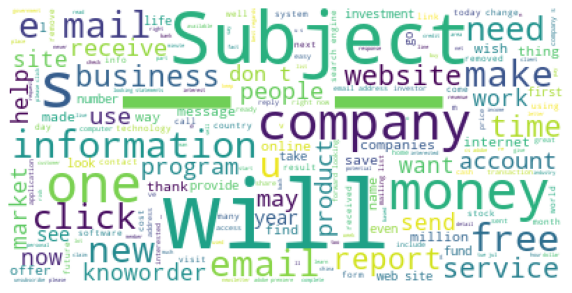

In [143]:
spam_words = ' '.join(list(data[data['spam']==1]['text']))
spam_cloud = WordCloud(background_color='white').generate(spam_words)

plt.figure(figsize=(10,8))
plt.imshow(spam_cloud)
plt.axis("off")
plt.show()

Notice that some words can be clearly associated to spam emails, such as 'money', 'click', and 'free'. Other words are instead less relevant, like 'Subject', 'will', 'company', etc. 
The next section will explain how to properly preprocess the emails in order to remove the words that have little relevance in spam classification.

## Preprocessing

While many emails would contain similar types of entities (e.g., numbers, URLs, or email addresses), the specific entities (e.g., the specific URL or dollar amount) will be different in almost every email. Therefore, one method often employed in processing emails is to normalize these values, so that all URLs are treated the same, all numbers are treated the same, etc. For example, we could replace each URL in the email with the unique string "httpaddr". This has the effect of letting the spam classifier make a decision based on the presence of any URL, rather than a specific URL. This typically improves the performance of a spam classifier, since spammers randomize the URLs, and thus the odds of seeing any particular URL again in a new piece of spam is very small. 

Specifically, the preprocessing should perform the following steps.

- **Lower-casing**: The entire email is converted into lower case, so that capitalization is ignored (e.g., *IndIcaTE* is treated the same as *Indicate*).

- **Stripping HTML**: All HTML tags are removed from the emails. Many emails often come with HTML formatting; we remove all the HTML tags, so that only the content remains.

- **Normalizing URLs**: All URLs are replaced with the text *httpaddr*.

- **Normalizing Emails**: All email addresses are replaced with the text *emailaddr*.

- **Normalizing Numbers**: All numbers are replaced with the text *number*.

- **Normalizing Dollars**: All dollar signs ($) are replaced with the text *dollar*.

- **Removal of non-words**: Non-words and punctuation are removed. All white spaces (tabs, newlines, spaces) are trimmed to a single space character.

- **Tokenization**: The email is broken down into a list of words. 

- **Word Lemmatization**: Words are truncated to their root. For example, *discount*, *discounts*, *discounted* and *discounting* are all replaced with "discount". Sometimes, the lemmatization strips off additional characters from the end, so *include*, *includes*, *included*, and *including* are all replaced with "includ".

### Quiz 4

> Complete the preprocessing steps in the function below.

*Hints:* 
 - Use the function `re.sub(arg1, arg2, arg3)` to identify any substring that maches a regular expression, and replace it with a string of your choice. This function takes 3 inputs: 
   - `arg1` - the regular expression, 
   - `arg2` - the new string that will replace all the matched substrings, 
   - `arg3` - the text that you want to modify. 
 - You are provided with all the regular expressions that you need to complete this exercise.
 - To check your work, you may add `print(text)` after each step. Remember to remove them when you are done.

In [144]:
def email_analyzer(text):
    import re
    
    # regular expressions
    url = r"((http[s]?[/: w.]*)|www[. ]*)[-a-zA-Z0-9@:%._\+~#=]{1,256}[. ]*[a-zA-Z0-9()]{1,6}\b(( / )*[-a-zA-Z0-9()!@:%_\+.~#?&\/\/=]*)*"
    html = '<[^<>]+>'
    money = '[$]+'
    email = r"[^@ \t\r\n]+([\ ]*@[\ ]*)[^@ \t\r\n]+([\ ]*\.[\ ]*)[^@ \t\r\n]{1,6}"
    number = '[0-9]+'
    punctuation = '[^\w\s]'
    
    # convert to lower case
    text = text.lower()
    
    # replace HTML tags with a single space
    text = re.sub(html," ",text)
    
    # replace URLs with the string 'httpaddr'
    text = re.sub(url,"httpaddr",text)
    
    # replace email addresses with the string 'emailaddr'
    text = re.sub(email,"emailaddr",text)
    
    # replace numbers with the string ' number ' (put a space before and after)
    text = re.sub(number,' number ',text)
    
    # replace dollars with the string ' dollar ' (put a space before and after)
    text = re.sub(money,' dollar ',text)
    
    # replace 'mail' with 'email'
    text = re.sub(r'\bmail\b', 'email', text)
    
    # remove punctuation
    text = re.sub(punctuation, ' ', text)
    
    # tokenize
    words = word_tokenize(text)
    
    # perform lemmization and remove stop-words
    stop = stopwords.words('english') + ['subject']
    engine = WordNetLemmatizer()
    words = [engine.lemmatize(w, 'v') for w in words if w not in stop]
    
    return words

In [149]:
import nltk
nltk.download('omw-1.4')
import numpy

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\SHAKTHI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [151]:
text = 'Checkout http:// www.rackspace.com/ for 10$. Send an mail to: groupname-unsubscribe@egroups.com'
words = email_analyzer(text)

numpy.testing.assert_equal(words, ['checkout', 'httpaddr', 'number', 'dollar', 'send', 'email', 'emailaddr'])

# If this cell raises an error, your implementation is *NOT* correct

The result of this preprocessing is shown below for a given email. While the preprocessing has left word fragments and non-words, this form turns out to be much easier to work with for performing spam classification.

In [152]:
print('BEFORE:\n')
print(email)
print('AFTER:\n')
print(email_analyzer(email))

BEFORE:

> Anyone knows how much it costs to host a web portal ?
>
Well, it depends on how many visitors you're expecting.
This can be anywhere from less than 10 bucks a month to a couple of $100. 
You should checkout http://www.rackspace.com/ or perhaps Amazon EC2 
if youre running something big..

To unsubscribe yourself from this mailing list, send an email to:
groupname-unsubscribe@egroups.com


AFTER:

['anyone', 'know', 'much', 'cost', 'host', 'web', 'portal', 'well', 'depend', 'many', 'visitors', 'expect', 'anywhere', 'less', 'number', 'buck', 'month', 'couple', 'dollar', 'number', 'checkout', 'httpaddr', 'perhaps', 'amazon', 'ec', 'number', 'youre', 'run', 'something', 'big', 'unsubscribe', 'mail', 'list', 'send', 'email', 'emailaddr']


## Feature extraction

After preprocessing the emails, we have a list of words for each email. The next step is to choose which words we would like to use in our classifier and which we would want to leave out. For this notebook, we have chosen only the most frequently occurring words as our set of words considered (the vocabulary list). Since words that occur rarely in the training set are only in a few emails, they might cause the model to over-fit our training set. 

The complete vocabulary list is in the file "vocab.txt", and also shown below:

```
1 aa           85 anymor       915 knew           1896 yourself
2 ab           86 anyon        916 know           1897 zdnet
3 abil         87 anyth        917 knowledg       1898 zero
...            ...             ...                1899 zip
```

Our vocabulary list was selected by choosing all words which occur at least a 100 times in the spam corpus, resulting in a list of 1899 words. In practice, a vocabulary list with about 10'000 to 50'000 words is often used. Given the vocabulary list, we can now map each word in the preprocessed emails into a list of word indices that contains the index of the word in the vocabulary list. 

The vocabulary allows us to convert each email into a numerical vector. In particular, this operation can be performed using the class `CountVectorizer` provided by Scikit-Learn. The cell below converts the email dataset into a matrix, where each line represents an email, and each colum corresponds to a word in the vocabulary. The element at position $(i,j)$ is equal to 1 if the $i$-th mail contains the $j$-th word. Therefore, each email is converted to a vector that looks like this:

$$
{\bf x} = (0,\dots,1,0,\dots,1,0,\dots,0).
$$

In [156]:
# load the vocabulary
with open('lab01_data/vocab.txt', 'r') as file:
    vocabulary = file.read()
    vocabulary = np.array([entry.split('\t')[-1] for entry in vocabulary.split('\n')[:-1]])
    
# setup the vectorizer
vectorizer = CountVectorizer(analyzer=email_analyzer, vocabulary=vocabulary, binary=True)

# convert the dataset
features = vectorizer.fit_transform(data['text'])
labels = data['spam'].values

Let us try again to visualize what are the most repeated words in the spam messages! 

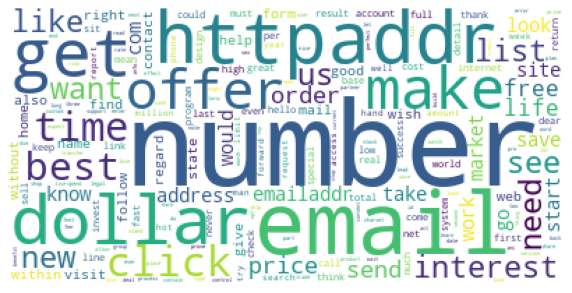

In [154]:
all_spam_words = np.concatenate(vectorizer.inverse_transform(features[labels==1]))
words, counts = np.unique(all_spam_words, return_counts=True)
spam_words = {k: v for k, v in zip(words, counts)}
spam_cloud = WordCloud(background_color='white').generate_from_frequencies(spam_words)

plt.figure(figsize=(10,8))
plt.imshow(spam_cloud)
plt.axis("off")
plt.show()

## SVM training

You are now ready to train a SVM for spam classification. The next cell splits the data into a **training set** and a **validation set**.

In [155]:
output = train_test_split(features, labels, test_size = 0.25, random_state=12)

features_train, features_test, labels_train, labels_test = output

### Quiz 5

> Train a **linear SVM** on the training set, and test its performance on the validation set.

*Note:* There is no need to normalize the data, since the features are 0/1 values.

In [31]:
model = LinearSVC()

... # YOUR CODE HERE

predictions = None # YOUR CODE HERE

accuracy = None # YOUR CODE HERE

print('Accuracy (test):', accuracy)

We would like to know which words the trained SVM thinks are the most predictive of spam. Remember that an email ${\bf x}\in\mathbb{R}^K$ is classified with the rule 

$$
y = 
\begin{cases}
1 &\textrm{if $\;\theta_0 + \theta^\top {\bf x} > 0$}
\\
0 &\textrm{otherwise}
\end{cases}
$$

where $\theta_0$ is the intercept (scalar), and $\theta$ is the vector of all the other coefficients (one per each entry in the vocabulary). Hence, the largest positive components in the vector $\theta$ are the most indicative words of spam.

### Quiz 6

> Which are the words associated to the 10 biggest components of $\theta$ ?

*Hints:* In the model `LinearSVC`, the vector $\theta$ is stored in the attribute `.coef_`.

```python
model = LinearSVC()
model.fit(x, y)
model.coef_     # Here is the vector of coefficients ! 
```

In [32]:
idx = None # YOUR CODE HERE
hot_words = None # YOUR CODE HERE

print(hot_words[:10])

### Quiz 7

> Now that you have trained a spam classifier, you can try it out on your own emails. We have included two non-spam emails (*emailSampleXXX.txt*) and two spam emails (*spamSampleXXX.txt*). Classify these emails with the trained SVM.
> - Does the classifier get right the other emails we provided? 
> - Based on the answer from the previous question, can you craft an email that is classified as spam?

*Hint:* Remember that you must preprocess the emails with `vectorizer.transform(emails)`before using the classifier.

In [33]:
emails = []

for name in ['emailSample1', 'emailSample2', 'spamSample1', 'spamSample2']:
    with open('lab01_data/' + name + '.txt', 'r') as file:
        emails += [file.read()]
        
emails = None # YOUR CODE HERE
preds = None # YOUR CODE HERE

print('Is spam?:', preds)

### Quiz 8

> Find the hyperparameter **C** leading to the best accuracy on the validation set. 

*Hint:* You should see that the classifier gets a test accuracy of 97.5\% or more.

In [34]:
# YOUR CODE HERE

Run the following cell and type `y`.

In [38]:
# EXECUTE THIS CELL **ONLY AFTER** YOU ANSWERED ALL THE QUIZZES

%reset

# Part 3. Step-by-step implementation

After experimenting with toy and real datasets, you should be quite confortable using SVM classifiers. So the time has come to better understand the theory behind them. To this end, you will now build a linear SVM from scratch!

## Required packages

For this part of the notebook, you need to import the following packages.
- [**Numpy**](www.numpy.org) - Library for scientific computing.
- [**Matplotlib**](http://matplotlib.org) - Library for plotting graphs.
- [**Autograd**](https://github.com/HIPS/autograd) - Library for automatic differentiation.

*Run the following cell.*

---

**Installation:** Autograd is not included in the standard Python installation. Open the terminal (Anaconda prompt on Windows) and execute the command:

```
pip install autograd
```

If you are not the admin, add the flag `--user` for a local installation, and **restart the notebook**.

In [1]:
import numpy
import autograd.numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

## Binary classification

In machine learning, binary classification is the problem of classifying instances into two classes. 

- You are given a set of input-output pairs 
$$
\begin{aligned}
\\
\mathcal{S} = \big\{({\bf x}^{(n)}, y^{(n)}) \;|\; n=1,\dots,N\big\}.\\
\\
\end{aligned}
$$
Here, the vector ${\bf x}^{(n)}\in \mathbb{R}^{Q}$ is an instance to be classified, and the associated label $y^{(n)}\in \{-1,1\}$ is the class to which it actually belongs. 


- Your goal is to learn a classifier that is capable of mapping the vectors ${\rm x}^{(n)}$ to their correct classes $y^{(n)}$.

The next figure shows a toy dataset of $N=150$ samples in a space of $Q=2$ dimensions divided in two classes. The points ${\bf x}^{(n)}$ colored blue have the label $y^{(n)}=1$, and those colored red have the label $y^{(n)}=-1$.

In [2]:
data = loadmat('lab01_data/data3.mat')

x_train = data['X']
y_train = data['y'].ravel()

y_train = 2 * y_train.astype(float) - 1 # binary labels (+1/-1)

plt.figure(figsize=(6,5))
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='coolwarm');

## Linear model

The building block of a binary classifier is the linear model. It is a function from $\mathbb{R}^{Q}$ to $\mathbb{R}$, whose output is controlled by a bunch of numbers called *parameters* or *weights*. Specifically, the transformation implemented by a linear model is parameterized by its weights, as shown in the figure below.

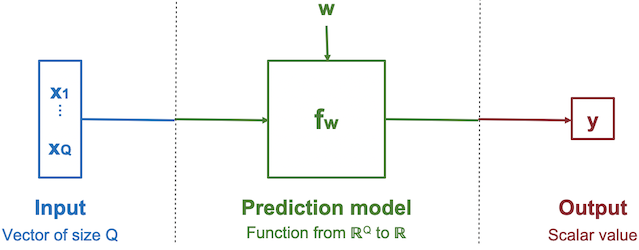

Let's delve into the mathematical details. The linear model takes as input a vector of length $Q$:

$$
{\bf x} = 
\begin{bmatrix}
x_1 \\
\vdots\\
x_Q\\
\end{bmatrix}
\in\mathbb{R}^{Q}.
$$

The model is parameterized by $Q+1$ weights:

$$
{\bf w} = 
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_Q
\end{bmatrix}
\in\mathbb{R}^{Q+1}.
$$

The weights are used to linearly transform an input vector as follows

$$
f_{\bf w}({\bf x}) = w_0 + w_1 x_1 + \dots + w_Q x_Q.
$$

Note that the weight $w_0$ does not multiply any coefficient of the input vector ${\bf x}$.

### Quiz 9

> **Implement the linear model defined above. Resort to a vectorized implementation, where the above computation can be applied to several input vectors without for-loops.**

> *Hints:*  The function `linear_model()` takes two arguments: 
>  - the vector `w` containing the weights ${\bf w}=[w_0, w_1,\dots, w_Q]^\top$,
>  - the matrix `x` stacking the vectors ${\bf x}^{(1)}, \dots, {\bf x}^{(N)}$ along its rows.
>
> The linear model can be efficiently computed by a single "matrix-vector" multiplication in order to obtain the output vector
>
>$$ 
\begin{bmatrix}
f_{\bf w}({\bf x}^{(1)}) \\
\vdots\\
f_{\bf w}({\bf x}^{(N)})
\end{bmatrix}
=
\begin{bmatrix}
w_0 + w_1 x_1^{(1)} + \dots + w_Q x_Q^{(1)} \\
\vdots\\
w_0 + w_1 x_1^{(N)} + \dots + w_Q x_Q^{(N)}
\end{bmatrix}.
$$
>
> Note however that the dimensions of `w` and `x` don't align for a matrix-vector multiplication, because
> - `w` is a vector of shape `(Q+1,)`
> - `x` is a matrix of shape `(N,Q)`.
> 
> To circumvent this issue, you can proceed as follows.
> - Slice `w` to select the elements from the position `1` to the end. *The syntax for slicing is `w[1:]`.*
> - Multiply `x` to the sliced array. *Use `@` for matrix-vector multiplication.*
> - Add `w[0]` to the result.

In [3]:
def linear_model(w, x):
    """
    INPUTS:
    w -- model weights | vector of shape (Q+1,  )
    x -- model inputs  | matrix of shape ( N , Q)

    OUTPUT:
    z -- model outputs | vector of shape (N,)
    """
    # Make sure that 'x' is a matrix
    x = x.reshape(x.shape[0], -1)
    
    # Compute the dot product of each row of 'x' by 'w'. Don't use a for loop!
    z = None # YOUR CODE HERE

    return z

In [9]:
w = np.array([-3, 2, 0.5, -1])
x = np.array([[4, -5,  2],
              [5,  3, -3],
              [5,  2,  1],
              [8,  6,  9],
              [5, -6,  2]])
z = linear_model(w, x)

numpy.testing.assert_almost_equal(z, [0.5, 11.5,  7. ,  7. ,  2.])

del w, x, z

# If this cell raises an error, your implementation is *NOT* correct

## Cost function

Initially, the weights of a linear model are randomly initialized. To properly adjust the weights, you need to measure how far this output is from what you expected. This is the job of the *cost function*, which computes the error between the model outputs and the expected answers. Choosing the proper loss function for the right problem is extremely important. Although there are many loss functions for the problem of binary classification, this notebook focuses on the following ones:
- the **logistic loss** function, which is used in logistic regression, 
- the **hinge loss** function, which is used in support vector machines.

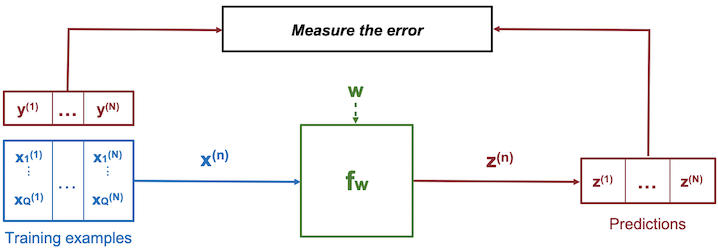

Let's delve into the mathematical details. The cost function measures the mean error incurred by the model to classify all the examples in the training set. Therefore, the general expression of this function consists of summing the classification error for each example $({\bf x}^{(n)}, y^{(n)})$, yielding:

$$
\textsf{Mean Error} = \frac{1}{N} \sum_{n=1}^N \mathcal{E}\big(f_{\bf w}({\bf x}^{(n)}), y^{(n)}\big).
$$

Here above, the term $\mathcal{E}(\cdot,\cdot)$ measures the error between the "real class" of the $n$-th sample and the model prediction (with given weights). The formula to measure this error is given below for both the "hinge loss" and the "logistic loss".

$$
\begin{aligned}
\mathcal{E}_{\sf hinge}(z, y) &= \max\{0, 1-yz\}
\\[0.5em]
\mathcal{E}_{\sf logistic}(z, y) &= \log(1+e^{-yz})
\end{aligned}
$$

As you will see later, these functions are used to train support vector machine and logistic regression, respectively.

### Quiz 10

> **Implement the "mean error" function using both the "hinge loss" and the "logistic loss" defined above.**

*Hint:* [`np.maximum`](https://numpy.org/doc/stable/reference/generated/numpy.maximum.html),
[`np.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html), [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)

In [5]:
def mean_error(w, x, y, which='hinge'):
    """
    INPUTS:
    w -- model weights | vector of shape (Q+1,)
    x -- model inputs  | matrix of shape (N, Q)
    y -- model outputs | vector of shape (N,)
    which -- 'hinge' or 'logistic'
    
    OUTPUT:
    error - mean error | scalar
    """
    
    # evaluate the linear model (use the function implemented before)
    z = None # YOUR CODE HERE
    
    # compute the error between the prediction and the expected output
    if which == 'hinge':
        error = None # YOUR CODE HERE
    else:
        error = None # YOUR CODE HERE
    
    return np.mean(error)

In [10]:
w = np.array([-3, 2, 0.5, -1])
x = np.array([[4, -5,  2],
              [5,  3, -3],
              [5,  2,  1],
              [8,  6,  9],
              [5, -6,  2]])
y = np.array([-1, 1, 1, 1, -1])

error_hinge = mean_error(w, x, y)
error_logit = mean_error(w, x, y, 'logistic')

numpy.testing.assert_almost_equal(error_hinge, 0.9)
numpy.testing.assert_almost_equal(error_logit, 0.6205676116345835)

del w, x, y

# If this cell raises an error, your implementation is *NOT* correct

## Training

Training a classifier consists of adjusting the weights of a (linear) model such that it will correctly classify the given set of examples. More specifically, the goal is to find the weights that allow the linear model to minimize the error as much as possible. This can be mathematically formulated as an optimization problem with respect to the the model weights:

$$
\operatorname*{minimize}_{{\bf w}\in\mathbb{R}^{Q+1}}\; \underbrace{\sum_{n=1}^N \mathcal{E}\big(f_{\bf w}({\bf x}^{(n)}), y^{(n)}\big)}_{J({\bf w})}.
$$

What comes next is to gradually adjust the weights based on the training data. To this end, you can take advantage of the fact that all operations used in the linear model are differentiable, and compute the gradient of the error function with regard to the weights. You can then move them in the opposite direction from the gradient to decrease the error. This boils down to an algorithm that repeats the following operation in a loop:

$$
{\bf w} \leftarrow {\bf w} - \alpha \nabla J({\bf w}).\\
$$

By choosing a sufficiently small $\alpha>0$, you will eventually end up with a model that incurs a very low error on the training data.

*Run the following cells to train support vector machine and logistic regression on the same data.*

In [24]:
def training(x, y, which, alpha, epochs):
    from autograd import grad
    from autograd.misc.optimizers import adam
    
    # gradient of the error function
    gradient = grad(lambda w, it: mean_error(w, x, y, which))
    
    # initialization
    w = np.zeros(x.shape[1]+1)
    
    # optimization
    w = adam(gradient, w, step_size=alpha, num_iters=epochs)
    
    return w

In [30]:
w_hinge = training(x_train, y_train, 'hinge', 0.1, 1000)
w_logit = training(x_train, y_train, 'logit', 0.1, 1000)

x = np.array([x_train[:,0].min(), x_train[:,0].max()])
z_hinge = - w_hinge[1]/w_hinge[2] * x - w_hinge[0]/w_hinge[2]
z_logit = - w_logit[1]/w_logit[2] * x - w_logit[0]/w_logit[2]

plt.figure(figsize=(8,6))
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='coolwarm', alpha=0.6)
plt.plot(x, z_hinge, 'k', label='SVM')
plt.plot(x, z_logit, 'k--', label='Logistic regression')
plt.legend(fontsize=14)
plt.show()